In [1]:
import os
import mlflow

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_pickle('../data/clean_data.pkl').sample(frac=0.1, random_state = 2)
df.info()
df=df.rename(columns={'income':'target'})
df['target'] = df['target'].apply(lambda x: 0 if x == '<=50K' \
                             else 1) 
df=df.drop(columns=['fnlwgt','education','native.country'])
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.25, random_state=2)


<class 'pandas.core.frame.DataFrame'>
Index: 3256 entries, 16054 to 17739
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             3256 non-null   int64   
 1   workclass       3256 non-null   category
 2   fnlwgt          3256 non-null   int64   
 3   education       3256 non-null   category
 4   education.num   3256 non-null   int64   
 5   marital.status  3256 non-null   category
 6   occupation      3256 non-null   category
 7   relationship    3256 non-null   category
 8   race            3256 non-null   category
 9   sex             3256 non-null   category
 10  capital.gain    3256 non-null   int64   
 11  capital.loss    3256 non-null   int64   
 12  hours.per.week  3256 non-null   int64   
 13  native.country  3256 non-null   category
 14  income          3256 non-null   category
dtypes: category(9), int64(6)
memory usage: 207.5 KB


In [3]:
cat_features = X_train.select_dtypes(include=['category','object']).columns.to_list()
cat_features


['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex']

In [4]:
num_features = X_train.select_dtypes(include=['number']).columns.to_list()
num_features

['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

In [5]:
from sklearn.ensemble import RandomForestClassifier
s_scaler = StandardScaler()
l_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999)
classifier=RandomForestClassifier()

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features), 
        ('cat', l_encoder, cat_features), 
    ],
    remainder='drop' )

In [7]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model',classifier)])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex'])])),
                ('model', RandomForestClassifier())])

In [8]:
from mlflow.models import infer_signature
input_example = X_train.head(5)
signature =  infer_signature(model_input = X_train.head(5))

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [9]:
y_test

17875    0
16235    0
23435    0
17989    1
10837    0
        ..
22774    0
13796    0
24066    0
24139    1
24324    0
Name: target, Length: 814, dtype: category
Categories (2, int64): [0, 1]

In [10]:
predictions = pipeline.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': np.float64(0.1547911547911548),
 'mape': np.float64(359624048868651.5),
 'mse': np.float64(0.1547911547911548)}

In [11]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

registry_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
tracking_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

mlflow.set_tracking_uri(tracking_uri)   
mlflow.set_registry_uri(registry_uri)   

In [15]:
EXPERIMENT_NAME = "estate_project"
RUN_NAME = "baseline model"
REGISTRY_MODEL_NAME = "estate_model_rf"

In [20]:
from mlflow.models import infer_signature

signature =  infer_signature(model_input = X_train.head(5))
input_example = X_train.head(5)
req_file = '../requirenments.txt'
art = '../comment.txt'
params_dict = pipeline.get_params()
#experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

# Впоследствии. чтобы добавлять запуски в этот же эксепримент мы должны получить его id:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(params_dict)

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

/home/mainuser/LR1_SM/IIS_LR1/my_venv/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2024/11/10 18:34:02 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlxtend (current: uninstalled, required: mlxtend==0.23.1

In [21]:
from sklearn.preprocessing import QuantileTransformer, SplineTransformer, PolynomialFeatures, MinMaxScaler

X_train_fe_sklearn = X_train.copy()

In [23]:
pf = PolynomialFeatures(degree=2)
X_train_fe_sklearn
pf.fit_transform(X_train_fe_sklearn[['capital.gain','capital.loss']])

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 1.4710000e+03, 0.0000000e+00, 2.1638410e+06,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.0000000e+00, 7.2980000e+03, 0.0000000e+00, 5.3260804e+07,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]])

In [25]:
# Значения преобразованных признаков нужно отскейлить, поэтому создаем pipeline из двух шагов - преобразование и скейлинг
pf_pipeline = Pipeline(steps=[
    ('poly', pf),
    ('scale', StandardScaler())
])

preprocessor_sklearn = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('poly', pf_pipeline, ['capital.gain','capital.loss']), # В преобразования добавляем созданный ранее pipeline
    ],
    remainder='drop',
    ) # Удаляем столбцы, которые не затронуты преобразования

In [26]:
X_train_fe_sklearn[['capital.gain','capital.loss']] = X_train_fe_sklearn[['capital.gain','capital.loss']].astype('float128')
X_train_fe_sklearn[['capital.gain','capital.loss']] = X_train_fe_sklearn[['capital.gain','capital.loss']].astype('float128')

X_train_sklearn_raw = preprocessor_sklearn.fit_transform(X_train_fe_sklearn)
X_train_sklearn = pd.DataFrame(X_train_sklearn_raw, columns=preprocessor_sklearn.get_feature_names_out())

with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_sklearn)

,num__age,num__education.num,num__capital.gain,num__capital.loss,num__hours.per.week,cat__workclass,cat__marital.status,cat__occupation,cat__relationship,cat__race,cat__sex,poly__1,poly__capital.gain,poly__capital.loss,poly__capital.gain^2,poly__capital.gain capital.loss,poly__capital.loss^2
0,0.451223,1.087806,-0.154977,-0.233165,0.740469,3.0,2.0,9.0,0.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
1,-1.205208,-0.447254,-0.154977,-0.233165,-0.056246,3.0,4.0,1.0,3.0,4.0,0.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,1.315447,-0.063489,-0.154977,-0.233165,-0.056246,1.0,0.0,7.0,1.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869
2441,2.755822,-0.447254,-0.154977,-0.233165,-2.048035,0.0,2.0,0.0,0.0,4.0,1.0,0.0,-0.154977,-0.233165,-0.082112,0.0,-0.213869


In [28]:
pipeline_sklearn = Pipeline(steps=[
    ('transform', preprocessor_sklearn),
    ('model', classifier)
])

model_sklearn = pipeline_sklearn.fit(X_train, y_train)

model_sklearn


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99999999),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex']),
                                                 ('poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['capital.gain',
                                                   'capital.loss'])])),
                ('model', RandomForestClassifier())])

In [29]:
predictions = model_sklearn.predict(X_test) 
metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'fe_sklearn'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(model_sklearn, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2024/11/10 19:42:07 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlxtend (current: uninstalled, required: mlxtend==0.23.1)
 - optuna (current: uninstalled, required: optuna==4.0.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2024/11/10 19:42:08 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlxtend (current: uninstalled, required: mlxtend==0.23.1)
 - optuna (current: uninstalled, required: optuna==4.0.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2024/11/10 19:42:08 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn a

In [54]:
X_train

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week
31099,45,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50
16198,22,Private,9,Never-married,Adm-clerical,Own-child,White,Female,0,0,40
4118,34,Federal-gov,13,Never-married,Exec-managerial,Unmarried,Asian-Pac-Islander,Male,1471,0,40
4143,24,Local-gov,10,Never-married,Protective-serv,Unmarried,Other,Male,1151,0,40
13727,39,Federal-gov,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,50
...,...,...,...,...,...,...,...,...,...,...,...
25681,24,?,13,Divorced,?,Not-in-family,White,Female,0,0,40
25344,21,Private,9,Never-married,Craft-repair,Other-relative,White,Male,0,0,40
2834,38,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,7298,0,50
15404,57,Federal-gov,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40


In [59]:
from autofeat import AutoFeatRegressor
transformations = ["1/", "exp", "log", "abs", "sqrt", "^2", "^3", "1+", "1-", "sin", "cos", "exp-", "2^"] 

afreg = AutoFeatRegressor(verbose=1, feateng_steps=2, max_gb=8, transformations=["log", "sqrt"],feateng_cols=num_features)

import numpy as np

class AutoFeatWrapper():
    def __init__(self, feateng_cols, feateng_steps=1, max_gb=16, transformations=["1/", "exp", "log"], n_jobs=-1, verbose=1):
        self.feateng_cols = feateng_cols
        self.feateng_steps = feateng_steps
        self.max_gb = max_gb
        self.transformations = transformations
        self.n_jobs = n_jobs
        self.afreg = AutoFeatRegressor(feateng_cols=self.feateng_cols,
                                     feateng_steps=self.feateng_steps,
                                     max_gb=self.max_gb,
                                     transformations=self.transformations,
                                     n_jobs=self.n_jobs)
        
    def fit(self, X, y=None):
        self.afreg.fit(X, y)
        return self
    
    def transform(self, X):
        return self.afreg.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        # Преобразуем данные и возвращаем имена фичей из DataFrame
        transformed_X = self.afreg.transform(pd.DataFrame(np.zeros((1, len(self.feateng_cols))), columns=self.feateng_cols))
        return transformed_X.columns.tolist()

afreg_pipeline = Pipeline(steps=[
    ('autofeat', AutoFeatWrapper( feateng_steps=2, max_gb=16, transformations=["log", "sqrt"],feateng_cols=num_features)),
    ('scaler', StandardScaler()),
])

preprocessor_afr = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('afr', afreg_pipeline, num_features), # преобразования autofeat
    ],
    remainder='drop', # Удаляем столбцы, которые не затронуты преобразованиями
    ) 

X_train_afr_raw =  preprocessor_afr.fit_transform(X_train,y_train)
X_train_afr = pd.DataFrame(X_train_afr_raw, columns=preprocessor_afr.get_feature_names_out())

with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_afr)



<lambdifygenerated-181>:2: RuntimeWarning: divide by zero encountered in log
  return log(t)
<lambdifygenerated-183>:2: RuntimeWarning: divide by zero encountered in log
  return log(t)


AttributeError: module 'sympy' has no attribute 'add'

In [36]:
from mlxtend.feature_selection import SequentialFeatureSelector 
#from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(RandomForestRegressor(n_estimators=3), 
                                k_features=3,
                                forward=True,
                                floating=False, # True to drop selected features
                                scoring='neg_mean_absolute_error',
                                cv=2)

sfs.fit(X_train_sklearn,y_train)

selected_features_sfs = X_train_sklearn.loc[:, sfs.k_feature_names_]
selected_features_sfs


,num__education.num,num__capital.gain,cat__relationship
0,1.087806,-0.154977,0.0
1,-0.447254,-0.154977,3.0
2,1.087806,0.041274,4.0
3,-0.063489,-0.001418,4.0
4,-0.447254,-0.154977,0.0
...,...,...,...
2437,1.087806,-0.154977,1.0
2438,-0.447254,-0.154977,2.0
2439,1.087806,0.818673,0.0
2440,-0.063489,-0.154977,1.0


In [37]:
rfe_sfs_idx = list(sfs.k_feature_idx_)
rfe_sfs_idx
rfe_sfs_col = list(sfs.k_feature_names_)
rfe_sfs_col


['num__education.num', 'num__capital.gain', 'cat__relationship']

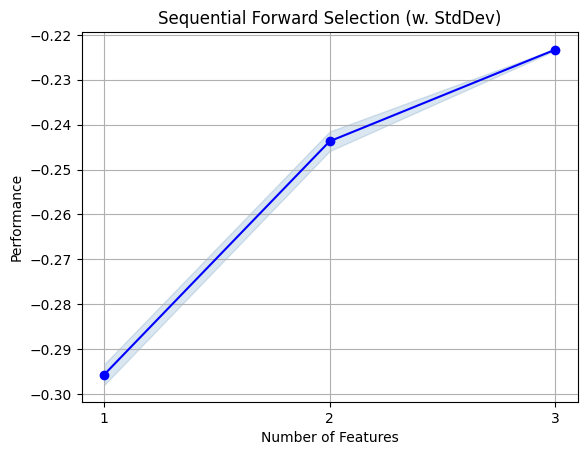

<Figure size 640x480 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()
plt.savefig('Sequential Forward Selection')


In [ ]:
rfe_sfs_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(rfe_sfs_idx)),
    ('model', classifier)
])

rfe_sfs_pipeline.fit(X_train, y_train)

